# 06: Random Forest Model

A population-weighted random forest that predicts `financially_fragile`—whether a respondent could **not** cover a $400 emergency expense with cash or its equivalent. This notebook compares a tree-based model with the logistic regression baseline using the same respondents, target, training/test split, and cross-validation folds.

**Input:** `data/processed/model_dataset_2025.csv` and `data/processed/model_dataset_2025_spec.json`, from `03_build_model_dataset.ipynb`.

**What this notebook does:**
1. Loads the shared model dataset and feature definitions
2. Preprocesses the features for a random forest
3. Tunes model settings using the shared training folds
4. Fits the selected model on all training rows and evaluates it on the held-out test set
5. Compares results with the reference baselines and logistic regression
6. Audits model performance across demographic groups
7. Tests how results change when the emergency-savings questions are excluded

All reported evaluation metrics use `weight_pop`, so they estimate performance for the U.S. adult population rather than the survey sample alone.

## 1. Imports and configuration

In [15]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    brier_score_loss,
    f1_score,
    log_loss,
    precision_score,
    recall_score,
    roc_auc_score,
    confusion_matrix
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder

RANDOM_STATE = 2344
THRESHOLD = 0.5

## Load the modeling data

Load the shared model dataset and feature specification created by `03_build_model_dataset.ipynb`. These provide the target, survey weights, and shared train/test split.

In [16]:
DATA_DIR = Path(".")

if not (DATA_DIR / "model_dataset_2025.csv").exists():
    DATA_DIR = Path("../data/processed")

if not (DATA_DIR / "model_dataset_2025.csv").exists():
    DATA_DIR = Path("data/processed")

print("Loading data from:", DATA_DIR.resolve())

data = pd.read_csv(DATA_DIR / "model_dataset_2025.csv", low_memory=False)

with open(DATA_DIR / "model_dataset_2025_spec.json", encoding="utf-8") as f:
    spec = json.load(f)

TARGET = spec["target"]["column"]
WEIGHT = spec["weight"]

NUMERIC = spec["features"]["numeric"]
CATEGORICAL = spec["features"]["categorical"]
ORDINAL = spec["features"]["ordinal"]

FEATURES = NUMERIC + CATEGORICAL + ORDINAL
FEATURES_NO_EF = [col for col in FEATURES if col not in spec["ef_module"]]

# Confirm the expected columns and feature exclusions.
required = FEATURES + [TARGET, WEIGHT, spec["id"], "split", "cv_fold"]
assert set(required).issubset(data.columns), "The modeling dataset is missing columns."
assert len(FEATURES) == len(set(FEATURES)), "The feature list contains duplicates."

excluded = {
    col
    for columns in spec["excluded"].values()
    for col in columns
}
assert not set(FEATURES) & (excluded | {TARGET, "split", "cv_fold"})

# Check IDs, target, weights, and saved split.
assert data[spec["id"]].notna().all() and data[spec["id"]].is_unique
assert data[TARGET].notna().all() and set(data[TARGET].unique()) == {0, 1}
assert np.isfinite(data[WEIGHT]).all() and (data[WEIGHT] > 0).all()
assert set(data["split"].unique()) == {"train", "test"}

# Separate the existing training and test rows.
train = data.loc[data["split"] == "train"].copy()
test = data.loc[data["split"] == "test"].copy()

folds = sorted(train["cv_fold"].unique())
assert folds == list(range(spec["cv"]["n_folds"]))
assert (test["cv_fold"] == spec["cv"]["test_fold"]).all()

for fold in folds:
    assert train.loc[train["cv_fold"] == fold, TARGET].nunique() == 2

assert test[TARGET].nunique() == 2

X_train, y_train, w_train = train[FEATURES], train[TARGET], train[WEIGHT]
X_test, y_test, w_test = test[FEATURES], test[TARGET], test[WEIGHT]

print(f"Train: {len(train):,} rows; test: {len(test):,} rows")
print(f"Features: {len(FEATURES)} with EF; {len(FEATURES_NO_EF)} without EF")
print(f"Weighted training fragility rate: {np.average(y_train, weights=w_train):.1%}")

Loading data from: /Users/ethanwang/Thrivent-1A-financial-resilience-map/data/processed
Train: 10,347 rows; test: 2,587 rows
Features: 425 with EF; 409 without EF
Weighted training fragility rate: 36.8%


## Preprocessing and model

In [17]:
def build_preprocessor(features):
    numeric = [col for col in NUMERIC if col in features]
    categorical = [col for col in CATEGORICAL if col in features]
    ordinal = [col for col in ORDINAL if col in features]

    numeric_pipeline = SimpleImputer(
        strategy="median",
        add_indicator=True,
        keep_empty_features=True,
    )

    categorical_pipeline = Pipeline([
        ("impute", SimpleImputer(
            strategy="constant",
            fill_value="__MISSING__",
        )),
        ("encode", OneHotEncoder(handle_unknown="ignore")),
    ])

    ordinal_pipeline = Pipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("encode", OrdinalEncoder(
            categories=[
                spec["features"]["ordinal_order"][col]
                for col in ordinal
            ],
            handle_unknown="use_encoded_value",
            unknown_value=-1,
        )),
    ])

    return ColumnTransformer([
        ("numeric", numeric_pipeline, numeric),
        ("categorical", categorical_pipeline, categorical),
        ("ordinal", ordinal_pipeline, ordinal),
    ])


def build_model(params, features):
    return Pipeline([
        ("preprocess", build_preprocessor(features)),
        ("model", RandomForestClassifier(
            n_estimators=200,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            **params,
        )),
    ])

## Choose model settings using cross-validation
Compare a small set of random-forest settings using the training data’s existing cross-validation folds. For each setting, the model trains on four folds and is evaluated on the fifth. I choose the setting with the lowest average weighted log loss. The test set is not used for tuning.

In [18]:
PARAMETERS = [
    {"max_depth": 10, "min_samples_leaf": 20, "max_features": "sqrt"},
    {"max_depth": 20, "min_samples_leaf": 20, "max_features": "sqrt"},
    {"max_depth": 10, "min_samples_leaf": 50, "max_features": "sqrt"},
    {"max_depth": 20, "min_samples_leaf": 50, "max_features": "sqrt"},
]

scores = []

for setting, params in enumerate(PARAMETERS):
    for fold in folds:
        fit_rows = train["cv_fold"] != fold
        valid_rows = train["cv_fold"] == fold

        model = build_model(params, FEATURES)

        # Rescale training weights to have a mean of 1.
        fit_weights = w_train.loc[fit_rows]
        fit_weights = fit_weights / fit_weights.mean()

        model.fit(
            X_train.loc[fit_rows, FEATURES],
            y_train.loc[fit_rows],
            model__sample_weight=fit_weights,
        )

        predictions = model.predict_proba(
            X_train.loc[valid_rows, FEATURES]
        )[:, 1]

        scores.append({
            "setting": setting,
            "fold": fold,
            "log_loss": log_loss(
                y_train.loc[valid_rows],
                predictions,
                sample_weight=w_train.loc[valid_rows],
            ),
        })

cv_results = pd.DataFrame(scores)

summary = (
    cv_results.groupby("setting")["log_loss"]
    .agg(["mean", "std"])
    .sort_values("mean")
)

display(summary)

best_setting = summary.index[0]
best_params = PARAMETERS[best_setting]

print("Selected settings:", best_params)

,mean,std
setting,,
1,0.358828,0.014105
0,0.360583,0.014164
3,0.369241,0.013767
2,0.370096,0.013983


Selected settings: {'max_depth': 20, 'min_samples_leaf': 20, 'max_features': 'sqrt'}


## Fit the selected model

After selecting the settings with cross-validation, I refit the random forest on all training rows. I then evaluate its predictions on the held-out test set. The test set has not been used to tune the model.

All metrics are weighted by `weight_pop`. Classification metrics use a probability threshold of 0.5.

In [19]:
final_model = build_model(best_params, FEATURES)

fit_weights = w_train / w_train.mean()

final_model.fit(
    X_train[FEATURES],
    y_train,
    model__sample_weight=fit_weights,
)

p_test = final_model.predict_proba(X_test[FEATURES])[:, 1]

## Fit Final Model

In [20]:
final_model = build_model(best_params, FEATURES)

final_model.fit(
    X_train,
    y_train,
    model__sample_weight=w_train / w_train.mean(),
)

p_test = pd.Series(
    final_model.predict_proba(X_test)[:, 1],
    index=test.index,
    name="predicted_fragility",
)

assert np.isfinite(p_test).all()
assert p_test.between(0, 1).all()

## Test performance

In [21]:
def evaluate(y_true, probabilities, weights):
    predicted = np.asarray(probabilities) >= THRESHOLD

    return {
        "ROC AUC": roc_auc_score(
            y_true, probabilities, sample_weight=weights
        ),
        "PR AUC": average_precision_score(
            y_true, probabilities, sample_weight=weights
        ),
        "Brier": brier_score_loss(
            y_true, probabilities, sample_weight=weights
        ),
        "Log loss": log_loss(
            y_true, probabilities, sample_weight=weights
        ),
        "Accuracy": accuracy_score(
            y_true, predicted, sample_weight=weights
        ),
        "Recall": recall_score(
            y_true, predicted, sample_weight=weights, zero_division=0
        ),
        "Precision": precision_score(
            y_true, predicted, sample_weight=weights, zero_division=0
        ),
        "F1": f1_score(
            y_true, predicted, sample_weight=weights, zero_division=0
        ),
    }


test_results = evaluate(y_test, p_test, w_test)
display(pd.DataFrame([test_results], index=["Random forest"]).round(3))

,ROC AUC,PR AUC,Brier,Log loss,Accuracy,Recall,Precision,F1
Random forest,0.919,0.869,0.111,0.36,0.851,0.767,0.819,0.792


## Confusion Matrix

In [22]:
labels = ["Not fragile", "Fragile"]
predicted = (p_test >= THRESHOLD).astype(int)

counts = confusion_matrix(y_test, predicted, labels=[0, 1])
weighted = confusion_matrix(
    y_test,
    predicted,
    labels=[0, 1],
    sample_weight=w_test,
)

display(pd.DataFrame(
    counts,
    index=labels,
    columns=labels,
).rename_axis(index="Actual", columns="Predicted"))

display(pd.DataFrame(
    100 * weighted / weighted.sum(),
    index=labels,
    columns=labels,
).rename_axis(
    index="Actual (% of weighted test sample)",
    columns="Predicted",
).round(1))

Predicted,Not fragile,Fragile
Actual,,
Not fragile,1533,147
Fragile,227,680


Predicted,Not fragile,Fragile
Actual (% of weighted test sample),,
Not fragile,56.7,6.3
Fragile,8.6,28.4


## Calibration

,rows,mean_predicted,observed_rate
bin,,,
"(0.00609, 0.0316]",259,0.022,0.009
"(0.0316, 0.0568]",259,0.044,0.011
"(0.0568, 0.0919]",258,0.073,0.055
"(0.0919, 0.145]",259,0.117,0.053
"(0.145, 0.245]",259,0.189,0.154
"(0.245, 0.38]",258,0.309,0.252
"(0.38, 0.531]",259,0.455,0.440
"(0.531, 0.695]",258,0.617,0.705
"(0.695, 0.839]",259,0.773,0.880


Expected calibration error: 0.049


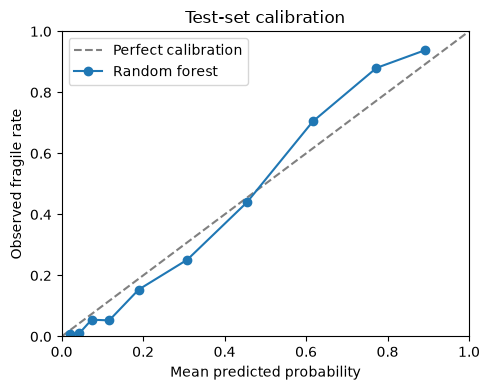

In [23]:
def weighted_calibration(y_true, probabilities, weights):
    frame = pd.DataFrame({
        "actual": np.asarray(y_true),
        "predicted": np.asarray(probabilities),
        "weight": np.asarray(weights),
    })

    frame["bin"] = pd.qcut(
        frame["predicted"],
        q=10,
        duplicates="drop",
    )

    frame["weighted_actual"] = frame["actual"] * frame["weight"]
    frame["weighted_predicted"] = frame["predicted"] * frame["weight"]

    table = frame.groupby("bin", observed=True).agg(
        rows=("actual", "size"),
        weight=("weight", "sum"),
        weighted_actual=("weighted_actual", "sum"),
        weighted_predicted=("weighted_predicted", "sum"),
    )

    table["mean_predicted"] = table["weighted_predicted"] / table["weight"]
    table["observed_rate"] = table["weighted_actual"] / table["weight"]

    ece = np.average(
        abs(table["mean_predicted"] - table["observed_rate"]),
        weights=table["weight"],
    )

    return table[["rows", "mean_predicted", "observed_rate"]], ece


calibration, ece = weighted_calibration(y_test, p_test, w_test)

display(calibration.round(3))
print(f"Expected calibration error: {ece:.3f}")

fig, ax = plt.subplots(figsize=(5, 4))
ax.plot([0, 1], [0, 1], "--", color="gray", label="Perfect calibration")
ax.plot(
    calibration["mean_predicted"],
    calibration["observed_rate"],
    "o-",
    label="Random forest",
)

ax.set(
    xlabel="Mean predicted probability",
    ylabel="Observed fragile rate",
    title="Test-set calibration",
    xlim=(0, 1),
    ylim=(0, 1),
)
ax.legend()
fig.tight_layout()
plt.show()

## Subgroup Audit

In [24]:
audit_rows = []

for column in ["race_5cat", "ppgender", "ppagecat", "pppa_lgb"]:
    for group, index in test.groupby(column, dropna=False).groups.items():
        y_group = y_test.loc[index]
        p_group = p_test.loc[index]
        w_group = w_test.loc[index]

        audit_rows.append({
            "attribute": column,
            "group": group,
            "rows": len(index),
            "actual rate": np.average(y_group, weights=w_group),
            "predicted rate": np.average(p_group, weights=w_group),
            "gap (pred - actual)": (
                np.average(p_group, weights=w_group)
                - np.average(y_group, weights=w_group)
            ),
            "recall": recall_score(
                y_group,
                p_group >= THRESHOLD,
                sample_weight=w_group,
                zero_division=0,
            ) if y_group.sum() else np.nan,
            "ROC AUC": roc_auc_score(
                y_group, p_group, sample_weight=w_group
            ) if y_group.nunique() == 2 else np.nan,
            "Brier": brier_score_loss(
                y_group, p_group, sample_weight=w_group
            ),
            "note": "small group" if len(index) < 100 else "",
        })

audit = pd.DataFrame(audit_rows)
display(audit.set_index(["attribute", "group"]).round(3))

rows  actual rate  predicted rate  \
attribute group                                                           
race_5cat Asian                        142        0.236           0.265   
          Black                        319        0.633           0.558   
          Hispanic                     339        0.505           0.506   
          Other                         64        0.686           0.594   
          White                       1723        0.277           0.287   
ppgender  Female                      1272        0.391           0.381   
          Male                        1315        0.350           0.353   
ppagecat  18-24                        208        0.566           0.570   
          25-34                        355        0.480           0.468   
          35-44                        435        0.474           0.435   
          45-54                        364        0.350           0.346   
          55-64                        492        0.281           0.289   
          65-74                        444        0.216           0.233   
          75+                          289        0.168           0.194   
pppa_lgb  Bisexual                      73        0.527           0.503   
          Gay or lesbian                75        0.434           0.424   
          Something else                53        0.602           0.552   
          Straight, that is, not gay  2137        0.344           0.342   
          __NOT_ASKED__                249        0.475           0.485   

                                      gap (pred - actual)  recall  ROC AUC  \
attribute group                                                              
race_5cat Asian                                     0.028   0.702    0.912   
          Black                                    -0.074   0.823    0.857   
          Hispanic                                  0.001   0.896    0.921   
          Other                                    -0.092   0.763    0.849   
          White                                     0.011   0.678    0.915   
ppgender  Female                                   -0.010   0.792    0.923   
          Male                                      0.003   0.739    0.914   
ppagecat  18-24                                     0.003   0.886    0.843   
          25-34                                    -0.013   0.836    0.933   
          35-44                                    -0.039   0.794    0.905   
          45-54                                    -0.004   0.706    0.932   
          55-64                                     0.008   0.677    0.916   
          65-74                                     0.017   0.652    0.908   
          75+                                       0.026   0.506    0.904   
pppa_lgb  Bisexual                                 -0.024   0.729    0.802   
          Gay or lesbian                           -0.010   0.794    0.936   
          Something else                           -0.049   0.873    0.886   
          Straight, that is, not gay               -0.003   0.752    0.921   
          __NOT_ASKED__                             0.009   0.840    0.913   

                                      Brier         note  
attribute group                                           
race_5cat Asian                       0.101               
          Black                       0.149               
          Hispanic                    0.115               
          Other                       0.148  small group  
          White                       0.102               
ppgender  Female                      0.112               
          Male                        0.111               
ppagecat  18-24                       0.163               
          25-34                       0.110               
          35-44                       0.127               
          45-54                       0.105               
          55-64                       0.100             

## Most relied Upon Features

In [25]:
preprocessor = final_model.named_steps["preprocess"]
encoded_names = preprocessor.get_feature_names_out()
encoded_importance = final_model.named_steps["model"].feature_importances_

importance_rows = []

for name, score in zip(encoded_names, encoded_importance):
    transformer, detail = name.split("__", 1)

    if transformer == "categorical":
        original = next(
            col for col in sorted(CATEGORICAL, key=len, reverse=True)
            if detail.startswith(col + "_")
        )
    elif detail.startswith("missingindicator_"):
        original = detail.removeprefix("missingindicator_")
    else:
        original = detail

    importance_rows.append({
        "feature": original,
        "importance": score,
    })

importance = (
    pd.DataFrame(importance_rows)
    .groupby("feature")["importance"]
    .sum()
    .sort_values(ascending=False)
)

display(importance.head(20).to_frame().round(4))

,importance
feature,
EF1,0.0786
EF2,0.0616
atleast_okay,0.0473
B2,0.0328
EF8_j,0.0328
K21_d,0.0304
EF8_e,0.0297
EF8_h,0.0280
C4A,0.0277


## Sensitivity Analysis

In [26]:
scores_no_ef = []

for setting, params in enumerate(PARAMETERS):
    for fold in folds:
        fit_rows = train["cv_fold"] != fold
        valid_rows = train["cv_fold"] == fold

        model = build_model(params, FEATURES_NO_EF)

        fit_weights = w_train.loc[fit_rows]
        fit_weights = fit_weights / fit_weights.mean()

        model.fit(
            X_train.loc[fit_rows, FEATURES_NO_EF],
            y_train.loc[fit_rows],
            model__sample_weight=fit_weights,
        )

        predictions = model.predict_proba(
            X_train.loc[valid_rows, FEATURES_NO_EF]
        )[:, 1]

        scores_no_ef.append({
            "setting": setting,
            "fold": fold,
            "log_loss": log_loss(
                y_train.loc[valid_rows],
                predictions,
                sample_weight=w_train.loc[valid_rows],
            ),
        })

cv_results_no_ef = pd.DataFrame(scores_no_ef)

summary_no_ef = (
    cv_results_no_ef.groupby("setting")["log_loss"]
    .agg(["mean", "std"])
    .sort_values("mean")
)

display(summary_no_ef)

best_setting_no_ef = summary_no_ef.index[0]
best_params_no_ef = PARAMETERS[best_setting_no_ef]

print("Selected settings without EF:", best_params_no_ef)

,mean,std
setting,,
1,0.383990,0.010058
0,0.386204,0.008759
3,0.396537,0.009205
2,0.397438,0.009218


Selected settings without EF: {'max_depth': 20, 'min_samples_leaf': 20, 'max_features': 'sqrt'}


In [27]:
model_no_ef = build_model(best_params_no_ef, FEATURES_NO_EF)

model_no_ef.fit(
    X_train[FEATURES_NO_EF],
    y_train,
    model__sample_weight=w_train / w_train.mean(),
)

p_test_no_ef = model_no_ef.predict_proba(
    X_test[FEATURES_NO_EF]
)[:, 1]

ef_comparison = pd.DataFrame({
    "Random forest (with EF)": evaluate(y_test, p_test, w_test),
    "Random forest (without EF)": evaluate(y_test, p_test_no_ef, w_test),
}).T

display(ef_comparison.round(3))

,ROC AUC,PR AUC,Brier,Log loss,Accuracy,Recall,Precision,F1
Random forest (with EF),0.919,0.869,0.111,0.360,0.851,0.767,0.819,0.792
Random forest (without EF),0.907,0.848,0.122,0.389,0.830,0.734,0.793,0.762
